## 1. Loading the Dataset

The corrupted posts dataset is loaded into a pandas DataFrame to examine its structure and contents before beginning the data cleaning process.


In [1]:
import pandas as pd

# Load the corrupted posts dataset
posts = pd.read_csv("Social_Engine_Posts_Corrupted.csv")

posts.head()

,post_id,user_id,platform,text_content,timestamp,likes,shares,comments
0,to64mgey2v3y,user_vfxs1pry,Reddit,Bummed out with my new Air Max from Nike! Abso...,25-09-2024,4488.0,1456,673
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,My one month review of Pepsi Crystal Pepsi: Hi...,1722528840,789.0,1484,39
2,dvvhg8eel45x,user_nfo3ih5u,NaN,Just unboxed my new Highlander from Toyota. Ex...,2025-04-13T20:12:18,NaN,1410,839
3,hgb9cxke4t7b,user_27aje6ur,Facebook,Comparing Pepsi Crystal Pepsi to the competiti...,10-09-2024,167.0,584,833
4,zwerpw3wk320,user_9px5q0by,Reddit,My one week review of Coca-Cola Diet Coke: Bes...,31-05-2024,4749.0,152,630


## 2. Initial Dataset Inspection

A preliminary inspection is performed to understand the size of the dataset, the available columns, and the data types of each field. This helps identify areas that may require cleaning or standardisation.

In [2]:
# Check the number of rows and columns
posts.shape

(12360, 8)

## 3. Column and Data Type Inspection

The column names and their corresponding data types are examined to understand how each field is currently stored and to identify columns that may need conversion during the cleaning process.

In [3]:
# Display column names and data types
posts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12360 entries, 0 to 12359
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   post_id       12360 non-null  object 
 1   user_id       12360 non-null  object 
 2   platform      10514 non-null  object 
 3   text_content  10614 non-null  object 
 4   timestamp     12360 non-null  object 
 5   likes         10502 non-null  float64
 6   shares        12360 non-null  int64  
 7   comments      12360 non-null  int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 772.6+ KB


## 4. Missing Values and Duplicate Records

Missing values and duplicate records are checked to identify incomplete or repeated entries that could affect the quality of the dataset.

In [4]:
# Check missing values and duplicate records
print("Missing values:")
print(posts.isnull().sum())

print("\nDuplicate rows:", posts.duplicated().sum())
print("Duplicate post IDs:", posts["post_id"].duplicated().sum())

Missing values:
post_id            0
user_id            0
platform        1846
text_content    1746
timestamp          0
likes           1858
shares             0
comments           0
dtype: int64

Duplicate rows: 360
Duplicate post IDs: 360


## 5. Removing Duplicate Records

Duplicate records were identified using both the complete row and `post_id`. Since 360 records were exact duplicates and the same 360 `post_id`s were repeated, these entries represent repeated copies of existing posts rather than unique posts. The duplicate records are therefore removed while keeping the first occurrence of each `post_id` to avoid counting the same post more than once.

In [5]:
# Remove duplicate posts while keeping the first occurrence
posts = posts.drop_duplicates(subset="post_id", keep="first").copy()

print("Rows after removing duplicates:", len(posts))
print("Duplicate post IDs remaining:", posts["post_id"].duplicated().sum())

Rows after removing duplicates: 12000
Duplicate post IDs remaining: 0


## 6. Handling Missing Values

Missing values were found in `platform`, `text_content`, and `likes`. Before replacing them, the missing entries are examined to determine an appropriate treatment for each column without introducing unsupported values into the dataset.

In [6]:
# Count missing values in the affected columns
posts[["platform", "text_content", "likes"]].isnull().sum()


,0
platform,1784
text_content,1688
likes,1814


## 7. Handling Missing Values

Missing values in the categorical columns are replaced with explicit labels instead of inventing values that cannot be determined from the dataset. For the numeric `likes` column, missing values are replaced with the median likes value, as the median provides a representative value while being less sensitive to unusually high or low engagement counts.

In [7]:
# Fill missing categorical values with clear placeholder labels
posts["platform"] = posts["platform"].fillna("Unknown")
posts["text_content"] = posts["text_content"].fillna("No text available")

# Fill missing likes using the median value
likes_median = posts["likes"].median()
posts["likes"] = posts["likes"].fillna(likes_median)

print("Missing values after treatment:")
print(posts[["platform", "text_content", "likes"]].isnull().sum())

Missing values after treatment:
platform        0
text_content    0
likes           0
dtype: int64


## 8. Standardising Timestamps

The `timestamp` column contains dates in multiple formats, including date strings, ISO-formatted timestamps, and Unix timestamps. These values are converted into a single datetime format so that the posts can be analysed consistently over time.

In [8]:
# Convert different timestamp formats into a consistent datetime format
def convert_timestamp(value):
    value = str(value).strip()

    # Handle Unix timestamps
    if value.isdigit():
        return pd.to_datetime(int(value), unit="s", errors="coerce")

    # Handle date and ISO timestamp formats
    return pd.to_datetime(value, dayfirst=True, errors="coerce")

posts["timestamp"] = posts["timestamp"].apply(convert_timestamp)

print("Invalid timestamps after conversion:", posts["timestamp"].isna().sum())
posts[["timestamp"]].head()

/tmp/ipykernel_2044/2731431211.py:10: UserWarning: Parsing dates in %Y-%m-%dT%H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(value, dayfirst=True, errors="coerce")


Invalid timestamps after conversion: 0


,timestamp
0,2024-09-25 00:00:00
1,2024-08-01 16:14:00
2,2025-04-13 20:12:18
3,2024-09-10 00:00:00
4,2024-05-31 00:00:00


## 9. Checking Numerical Anomalies

The engagement columns are checked for invalid negative values. Since likes, shares, and comments represent interaction counts, negative values would indicate inconsistent or corrupted records and would require further treatment.

In [9]:
# Check for negative engagement values
engagement_cols = ["likes", "shares", "comments"]

(posts[engagement_cols] < 0).sum()

,0
likes,509
shares,0
comments,0


## 10. Handling Negative Likes

A total of 509 records contain negative values in the `likes` column. Since likes represent the number of positive interactions on a post, negative values are not valid. These values are treated as missing and replaced using the median likes value to preserve the affected records without introducing an arbitrary value.

In [10]:
# Treat negative likes as invalid values
posts.loc[posts["likes"] < 0, "likes"] = pd.NA

# Replace the invalid values with the median likes value
posts["likes"] = posts["likes"].fillna(posts["likes"].median())

print("Negative likes remaining:", (posts["likes"] < 0).sum())

Negative likes remaining: 0


## 11. Final Cleaning Check

A final check is performed to confirm that the main data quality issues identified during the cleaning process have been addressed before exploratory analysis.

In [11]:
# Verify missing values and duplicate records after cleaning
print("Total missing values:", posts.isnull().sum().sum())
print("Duplicate rows:", posts.duplicated().sum())
print("Duplicate post IDs:", posts["post_id"].duplicated().sum())
print("Invalid timestamps:", posts["timestamp"].isna().sum())
print("Negative likes:", (posts["likes"] < 0).sum())

Total missing values: 0
Duplicate rows: 0
Duplicate post IDs: 0
Invalid timestamps: 0
Negative likes: 0


## 12. Platform Distribution

The distribution of posts across platforms is examined to understand which platforms contribute the most records to the dataset.

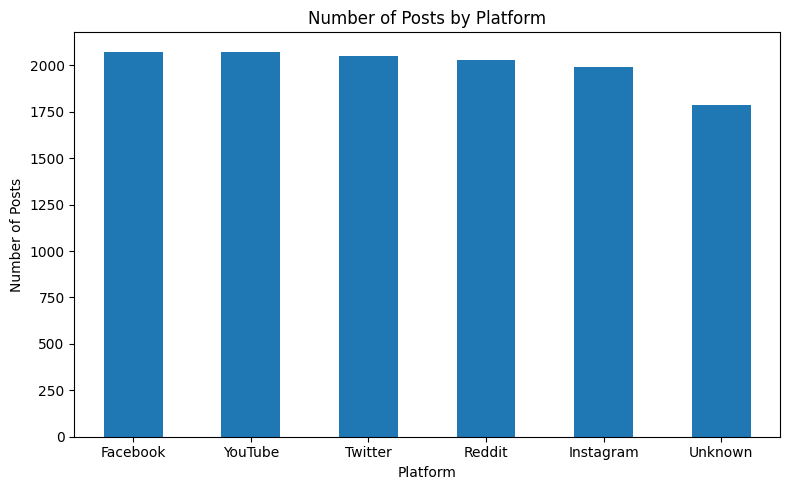

,count
platform,
Facebook,2074
YouTube,2073
Twitter,2049
Reddit,2031
Instagram,1989
Unknown,1784


In [12]:
import matplotlib.pyplot as plt

platform_counts = posts["platform"].value_counts()

plt.figure(figsize=(8, 5))
platform_counts.plot(kind="bar")
plt.title("Number of Posts by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Posts")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

platform_counts

## 13. Engagement Distribution

The distribution of likes, shares, and comments is visualised to understand the spread of engagement values and identify unusually high or low observations.

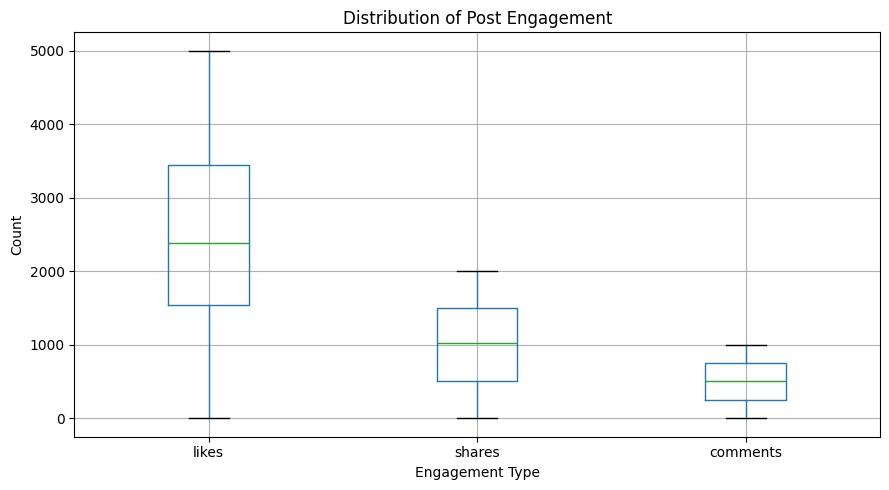

In [14]:
engagement_cols = ["likes", "shares", "comments"]

plt.figure(figsize=(9, 5))
posts[engagement_cols].boxplot()
plt.title("Distribution of Post Engagement")
plt.xlabel("Engagement Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 14. Posting Activity Over Time

The number of posts over time is analysed to identify periods of higher or lower posting activity and observe the overall posting pattern.

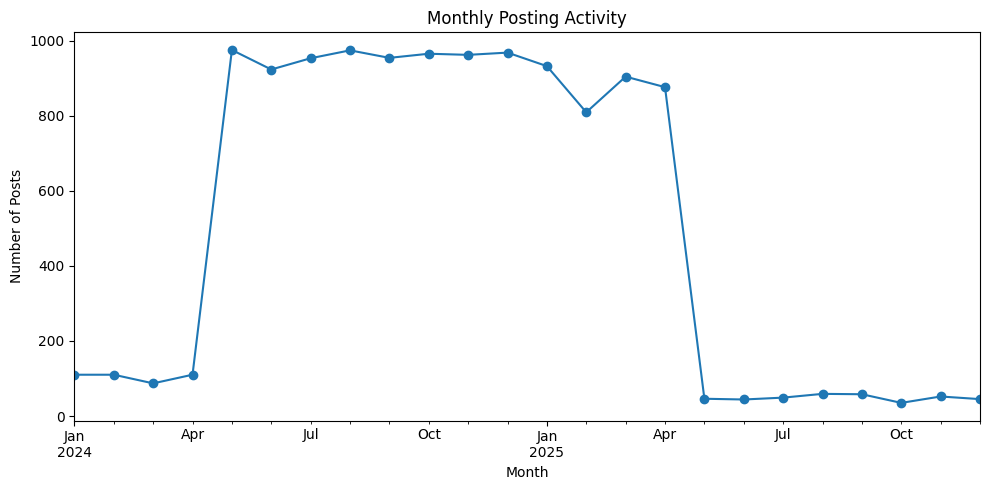

In [15]:
monthly_posts = posts.set_index("timestamp").resample("ME").size()

plt.figure(figsize=(10, 5))
monthly_posts.plot(kind="line", marker="o")
plt.title("Monthly Posting Activity")
plt.xlabel("Month")
plt.ylabel("Number of Posts")
plt.tight_layout()
plt.show()

## 15. Top Posts by Engagement

An overall engagement score is calculated by combining likes, shares, and comments. The highest-engagement posts are then examined to identify the records that received the strongest user interaction.

In [16]:
posts["total_engagement"] = (
    posts["likes"] + posts["shares"] + posts["comments"]
)

top_posts = posts.nlargest(10, "total_engagement")[
    ["post_id", "platform", "likes", "shares", "comments", "total_engagement"]
]

top_posts

,post_id,platform,likes,shares,comments,total_engagement
12227,ycjj5zzt7mvx,Instagram,4983.0,1919,991,7893.0
3675,wo7py9aljg3t,Reddit,4864.0,1981,948,7793.0
10583,gmoeib832zbs,Facebook,4902.0,1880,982,7764.0
3350,5kvuyvf38nqx,YouTube,4923.0,1971,861,7755.0
8889,pvfl3d8hj7jd,Instagram,4989.0,1840,909,7738.0
8578,tdgjjylpua20,Unknown,4979.0,1932,812,7723.0
5201,tne7s3o4l4wd,Instagram,4931.0,1903,878,7712.0
6738,a1kiwl618kzy,Facebook,4811.0,1952,920,7683.0
8934,fp89q1ickn9w,Twitter,4740.0,1933,955,7628.0
6646,5n161ir5hhhr,YouTube,4751.0,1981,878,7610.0


## 16. Relationship Between Engagement Metrics

The relationship between likes, shares, and comments is examined to determine whether higher activity in one engagement metric is associated with higher activity in the others.

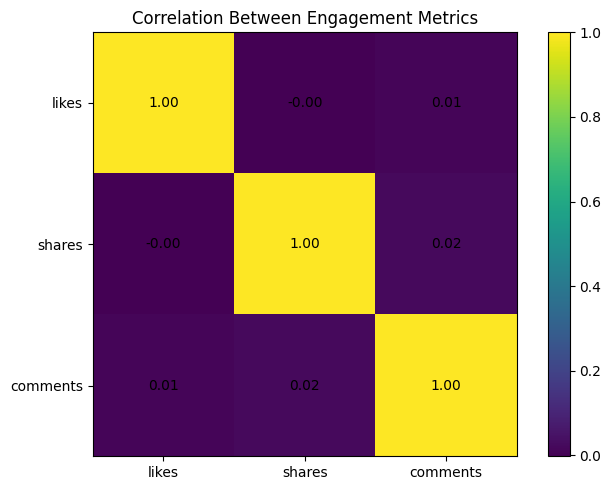

,likes,shares,comments
likes,1.000000,-0.002278,0.011437
shares,-0.002278,1.000000,0.024406
comments,0.011437,0.024406,1.000000


In [17]:
correlation = posts[["likes", "shares", "comments"]].corr()

plt.figure(figsize=(7, 5))
plt.imshow(correlation, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Between Engagement Metrics")

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(j, i, f"{correlation.iloc[i, j]:.2f}",
                 ha="center", va="center")

plt.tight_layout()
plt.show()

correlation

## Overall EDA Findings

The exploratory analysis shows that posts are distributed fairly evenly across the available platforms, although some platform values were missing and were retained as `Unknown`. Engagement levels vary considerably, with likes generally higher than shares and comments. Posting activity changes noticeably across the timeline, with higher activity during much of 2024 and early 2025 followed by a sharp decline. The highest-engagement posts are distributed across multiple platforms rather than being concentrated on a single platform. The correlation analysis also shows very weak relationships between likes, shares, and comments, indicating that these engagement measures vary largely independently in the cleaned dataset.

## 17. Final Data Validation

A final validation is performed to confirm that the cleaned dataset contains no missing values, duplicate records, invalid timestamps, or negative engagement values.

In [18]:
print("Final dataset shape:", posts.shape)
print("Total missing values:", posts.isnull().sum().sum())
print("Duplicate rows:", posts.duplicated().sum())
print("Duplicate post IDs:", posts["post_id"].duplicated().sum())
print("Invalid timestamps:", posts["timestamp"].isna().sum())
print("Negative likes:", (posts["likes"] < 0).sum())
print("Negative shares:", (posts["shares"] < 0).sum())
print("Negative comments:", (posts["comments"] < 0).sum())

Final dataset shape: (12000, 9)
Total missing values: 0
Duplicate rows: 0
Duplicate post IDs: 0
Invalid timestamps: 0
Negative likes: 0
Negative shares: 0
Negative comments: 0


### Note on Dataset Columns

The dataset contained 8 original columns. During EDA, a temporary `total_engagement` column was created by combining likes, shares, and comments to support engagement analysis. This derived column was used only for exploratory analysis and was removed before exporting the final cleaned dataset. Therefore, the final submitted dataset correctly contains 8 columns.

## 18. Exporting the Cleaned Dataset

The cleaned dataset is exported as a CSV file for submission and further use in the next phase of the competition.

In [19]:
# Remove the temporary EDA column before exporting
posts_cleaned = posts.drop(columns=["total_engagement"])

posts_cleaned.to_csv("Social_Engine_Posts_Cleaned.csv", index=False)

print("Cleaned dataset exported successfully.")
print("Final shape:", posts_cleaned.shape)

Cleaned dataset exported successfully.
Final shape: (12000, 8)
